## Assignment 3 – Julia Widén
Python Programming for Business Intelligence

### Task 0

In [1]:
!pip install openai -q  # -q to make the notebook look less messy

# a)
from openai import OpenAI

# connect to the local Ollama server
ollama_client = OpenAI(
    base_url = "http://localhost:11434/v1/",
    api_key = "ollama"  # required by the library but ignored by Ollama
)

In [2]:
# b)

# creating helper function to send a prompt and return the response
def ask_llm(prompt):
    """Send a prompt to the local LLM and return the response text."""
    response = ollama_client.chat.completions.create(
        model = MODEL,
        messages = [
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content


MODEL = "gemma3:270m"  # setting the model to the 270m parameter version

# testing the model with a simple prompt
print(ask_llm("What is 24 times 60? Answer in one sentence."))

24 times 60 is 1200.



In [3]:
# c)

MODEL = "gemma3:4b"  # setting the model to the 270m parameter version

# testing the model with the same prompt as in b)
print(ask_llm("What is 24 times 60? Answer in one sentence."))

24 times 60 equals 1440.


**Commnent on Task 0 b and c:** The 270m model answered 1200 which is incorrect. This shows that the 270m parameter version is very small and can struggle with basic maths. The 4b model answered 1440 which is correct, showing the size of the model can impact accuracy :)

### Task 1

In [4]:
# setup

import pandas as pd
 
emails = pd.read_csv('data/emails.csv',sep = ';')   # loading the email headlines dataset 
display(emails.head())

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


In [5]:
# a) 

CATEGORIES = ["spam", "work", "unknown"]

def classify_email(headline):
    """Classify an email headline as spam, work or unknown."""
    prompt = f"""Classify the following email headline as exactly one of: spam, work, or unknown.
Return only the classification word and nothing else.
Headline: {headline}"""
    result= ask_llm(prompt)
    return result.strip()  # .strip() to clean output

In [6]:
# b)

MODEL = "gemma3:270m"

emails["predicted_270m"] = emails["headline"].apply(classify_email)
display(emails[["headline", "predicted_270m"]])

,headline,predicted_270m
0,URGENT: Your account will be suspended within ...,Suspended
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


In [7]:
# b)

MODEL = "gemma3:4b"

emails["predicted_4b"] = emails["headline"].apply(classify_email)
display(emails[["headline", "predicted_4b"]])

,headline,predicted_4b
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",work
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",work
8,Quick question about last week,unknown
9,Following up,unknown


**Commnent on Task 1 b and c:** 
As expected based on Task0 we can see that once again the 270 model is too small to give any reliable answers while the 4b model performed much better, identifying spam, work and unknown emails, showing that larger models are better at following instructions. However, we can clearly see that the 4b model isn't without faults, for example categorizing "Are you available?" as spam. 

In [8]:
# d)

results_270m = []
results_4b = []

# running classification 3 times for both models
for i in range(3):
    # 270m model
    MODEL = "gemma3:270m"
    results_270m.append(emails["headline"].apply(classify_email))
    
    # 4b model
    MODEL = "gemma3:4b"
    results_4b.append(emails["headline"].apply(classify_email))

# building dfs for both models
df_270m = pd.DataFrame({
    "headline": emails["headline"],
    "run1": results_270m[0],
    "run2": results_270m[1],
    "run3": results_270m[2]
})

df_4b = pd.DataFrame({
    "headline": emails["headline"],
    "run1": results_4b[0],
    "run2": results_4b[1],
    "run3": results_4b[2]
})

print("270m model results:")
display(df_270m)

print("4b model results:")
display(df_4b)

270m model results:


,headline,run1,run2,run3
0,URGENT: Your account will be suspended within ...,Suspended,Suspended,Suspended
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,unknown,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,spam,spam
5,"Q3 budget report attached, please review by Fr...",spam,spam,spam
6,Reminder: Annual performance review scheduled ...,Reminder,spam,Reminder
7,"Updated draft of the manuscript, comments welcome",spam,spam,spam
8,Quick question about last week,spam,spam,spam
9,Following up,spam,spam,spam


4b model results:


,headline,run1,run2,run3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,unknown,unknown,unknown


**Comment on Task 1 d:** 
LLMs are probabilistic, so running the same prompt twice may produce slightly different or inaccurate results. The 270m model categorized most emails as spam all three times while the 4b model was clearly more accurate and consistent.

### Task 2

In [9]:
# setup

import json

news = pd.read_csv("data/news.csv", sep = ';')
display(news.head())

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...


In [10]:
# a)

def classify_news(headline):
    """Return topic and sentiment for a news headline in JSON format."""
    prompt = f"""Analyse the following financial news headline.
Return your answer as a JSON object with two keys:
- "topic": one of "earnings", "mergers", "regulation", "macroeconomics"
- "sentiment": one of "positive", "negative", "neutral"

Do not include any other text, markdown formatting, or code blocks. Return only the JSON object.

Headline: {headline}"""
    result = ask_llm(prompt)
    # Clean the response in case the model wraps it in markdown code fences
    cleaned = result.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    return json.loads(cleaned)

In [11]:
# b)

MODEL = "gemma3:4b"

details = news["headline"].apply(classify_news)
news["topic"] = details.apply(lambda d: d.get("topic", ""))
news["sentiment"] = details.apply(lambda d: d.get("sentiment", ""))

display(news[["headline", "topic", "sentiment"]])

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


**c)**

Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% ->  earnings, positive

Helvora Pharmaceuticals misses earnings forecast amid weak generics demand -> earnings, negative


Aurelis Bank reports steady quarterly profit, in line with analyst expectations -> earnings, neutral

Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal -> mergers, positive

Antitrust regulators block proposed merger between Solenta and Marvex Energy -> mergers, negative

Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG -> mergers, neutral

New EU AI Act compliance rules expected to raise costs for Lumavex by 12% -> regulation, negative

Finnish FSA grants Norvik Capital expanded licence for cross-border operations -> regulation, positive

Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs -> macroeconomics, positive

Rising interest rates weigh on Tessaro Real Estate as financing costs climb -> macroeconomics, negative


**Comment on Task 2 c:** I used ChatGPT for this task and both models agreed on most classifications. The main difference was row 2 where 4b model said positive while ChatGPT said neutral, which seems more accurate as steady profit in line with expectations is neither good nor bad news. Overall, ChatGPT seems to be a bit more accurate, probably because of the size difference in the models.

### Task 3

In [12]:
# setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# a) 

df = pd.read_csv("data/bank-additional.csv", sep = ";")  # loadfing data

In [14]:
# inspecting the first few rows to see that the data loaded correctly
df.head().round(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.89,-46.2,1.31,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.99,-36.4,4.86,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.46,-41.8,4.96,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.46,-41.8,4.96,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.20,-42.0,4.19,5195.8,no


In [15]:
# inspecting column names, non-null counts and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [16]:
# looking at the summary statistics for numeric columns.
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00
mean,40.11,256.79,2.54,960.42,0.19,0.08,93.58,-40.50,3.62,5166.48
std,10.31,254.70,2.57,191.92,0.54,1.56,0.58,4.59,1.73,73.67
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60
25%,32.00,103.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.33,5099.10
50%,38.00,181.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,317.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,88.00,3643.00,35.00,999.00,6.00,1.40,94.77,-26.90,5.04,5228.10


y
no     3668
yes     451
Name: count, dtype: int64


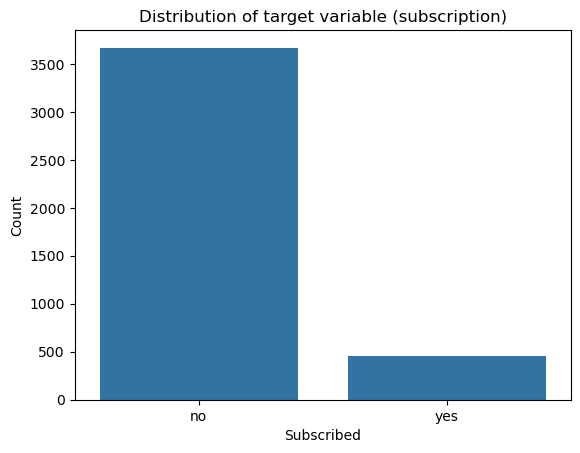

In [17]:
# checking class balance of the target variable "subscription"
print(df["y"].value_counts())
sns.countplot(x = "y", data = df)
plt.title("Distribution of target variable (subscription)")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.show()

In [18]:
# b)

# encoding target variable: yes -> 1, no -> 0
df["y"] = df["y"].map({"yes": 1, "no": 0})

# encoding categorical columns using one-hot encoding, drop_first=True avoids multicollinearity (features being too correlated with each other)
df_encoded = pd.get_dummies(df, drop_first = True)

df_encoded.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


In [19]:
# separating features (X) and target (y)
X = df_encoded.drop("y", axis = 1)
y = df_encoded["y"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (4119, 53)
Target shape: (4119,)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# splitting into train (70%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# scaling the features, this ensures the model never sees test data statistics during training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

Training set size: (2883, 53)
Test set size: (1236, 53)


**c)**

*This is a classification task since we are predicting whether a customer will subscribe to a term deposit or not, which is a binary outcome (yes/no) rather than a continuous numerical value.*

**I chose the following three classification algorithms:**

**Random Forest:** An ensemble method that combines multiple decision trees, making it robust and well suited for datasets with many features like this one.
**KNN (K-Nearest Neighbors):** A simple but effective algorithm that classifies based on similarity to neighboring data points, good as a baseline model.
**Logistic Regression:** A natural choice for binary classification tasks like this one where the target variable has only two outcomes (yes/no).

In [21]:
# setup 

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# below I'm training initial models with default hyperparameters


In [22]:
# random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [23]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [24]:
# logistic regression
lr_model = LogisticRegression(random_state=42, max_iter=2000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [25]:
# evaluating initial models before tuning
for name, model in [("Random Forest", rf_model), ("KNN", knn_model), ("Logistic Regression", lr_model)]:
    pred = model.predict(X_test_scaled)
    print(f"\n{name}:")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))


Random Forest:
[[1064   41]
 [  83   48]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1105
           1       0.54      0.37      0.44       131

    accuracy                           0.90      1236
   macro avg       0.73      0.66      0.69      1236
weighted avg       0.89      0.90      0.89      1236


KNN:
[[1083   22]
 [ 102   29]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      1105
           1       0.57      0.22      0.32       131

    accuracy                           0.90      1236
   macro avg       0.74      0.60      0.63      1236
weighted avg       0.88      0.90      0.88      1236


Logistic Regression:
[[1059   46]
 [  75   56]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1105
           1       0.55      0.43      0.48       131

    accuracy                           0.90      1236
   

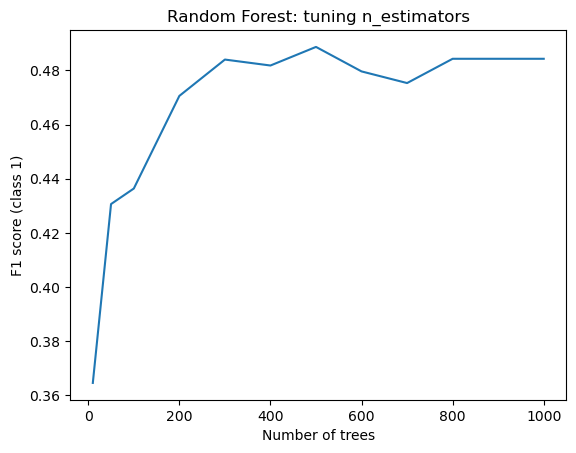

Best n_estimators: 500


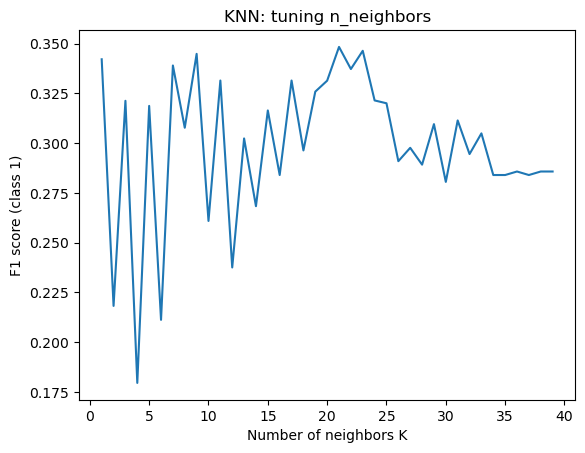

Best K: 21


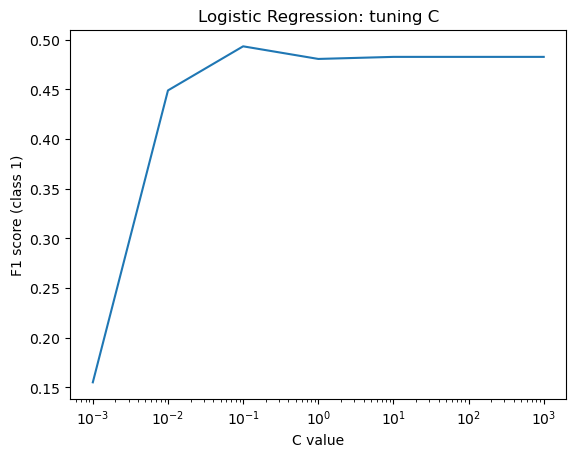

Best C: 0.1


In [26]:
# adjusting the hyperparameters to improve performance

from sklearn.metrics import f1_score

# tuning random forest by trying different number of trees
n_estimators_range = [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
rf_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_scaled, y_train)
    pred = rf.predict(X_test_scaled)
    rf_scores.append(f1_score(y_test, pred))

plt.plot(n_estimators_range, rf_scores)
plt.xlabel("Number of trees")
plt.ylabel("F1 score (class 1)")
plt.title("Random Forest: tuning n_estimators")
plt.show()

print(f"Best n_estimators: {n_estimators_range[rf_scores.index(max(rf_scores))]}")

# tuning KNN by trying different values of k
neighbors = list(range(1, 40))
knn_scores = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    knn_scores.append(f1_score(y_test, pred))

plt.plot(neighbors, knn_scores)
plt.xlabel("Number of neighbors K")
plt.ylabel("F1 score (class 1)")
plt.title("KNN: tuning n_neighbors")
plt.show()

print(f"Best K: {neighbors[knn_scores.index(max(knn_scores))]}")

# tuning logistic regression by trying different values of C
C_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
lr_scores = []

for c in C_range:
    lr = LogisticRegression(C=c, random_state=42, max_iter=2000)
    lr.fit(X_train_scaled, y_train)
    pred = lr.predict(X_test_scaled)
    lr_scores.append(f1_score(y_test, pred))

plt.plot(C_range, lr_scores)
plt.xlabel("C value")
plt.ylabel("F1 score (class 1)")
plt.title("Logistic Regression: tuning C")
plt.xscale("log")
plt.show()

print(f"Best C: {C_range[lr_scores.index(max(lr_scores))]}")

In [27]:
# retraining final models with optimal hyperparameters
rf_final = RandomForestClassifier(n_estimators=500, random_state=42)
rf_final.fit(X_train_scaled, y_train)

knn_final = KNeighborsClassifier(n_neighbors=21)
knn_final.fit(X_train_scaled, y_train)

lr_final = LogisticRegression(C=0.1, random_state=42, max_iter=2000)
lr_final.fit(X_train_scaled, y_train)

# evaluating final models
for name, model in [("Random Forest", rf_final), ("KNN", knn_final), ("Logistic Regression", lr_final)]:
    pred = model.predict(X_test_scaled)
    print(f"\n{name}:")
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred))


Random Forest:
[[1069   36]
 [  77   54]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1105
           1       0.60      0.41      0.49       131

    accuracy                           0.91      1236
   macro avg       0.77      0.69      0.72      1236
weighted avg       0.90      0.91      0.90      1236


KNN:
[[1089   16]
 [ 100   31]]
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1105
           1       0.66      0.24      0.35       131

    accuracy                           0.91      1236
   macro avg       0.79      0.61      0.65      1236
weighted avg       0.89      0.91      0.89      1236


Logistic Regression:
[[1065   40]
 [  75   56]]
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1105
           1       0.58      0.43      0.49       131

    accuracy                           0.91      1236
   

In [28]:
# d)

from sklearn.model_selection import cross_val_score

# cross-validation with 5 folds for each model
for name, model in [("Random Forest", rf_final), ("KNN", knn_final), ("Logistic Regression", lr_final)]:
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="f1")
    print(f"\n{name}:")
    print(f"CV F1 scores per fold: {cv_scores.round(3)}")
    print(f"Mean CV F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
    
    
    # comparing to test set score
    pred = model.predict(X_test_scaled)
    test_f1 = f1_score(y_test, pred)
    print(f"Test set F1: {test_f1:.3f}")


Random Forest:
CV F1 scores per fold: [0.46  0.511 0.493 0.483 0.484]
Mean CV F1: 0.486 (+/- 0.016)
Test set F1: 0.489

KNN:
CV F1 scores per fold: [0.538 0.484 0.463 0.438 0.503]
Mean CV F1: 0.485 (+/- 0.034)
Test set F1: 0.348

Logistic Regression:
CV F1 scores per fold: [0.517 0.507 0.521 0.466 0.566]
Mean CV F1: 0.515 (+/- 0.032)
Test set F1: 0.493


**Comment on Task 3 d:** CV produced higher and more reliable F1 scores than the single train/test split for all three models. This is because cross-validation uses all the data across 5 folds, reducing the risk of getting lucky or unlucky with a single split.

In [29]:
# e)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# collecting metrics for all models
metrics = {}

for name, model in [("Random Forest", rf_final), ("KNN", knn_final), ("Logistic Regression", lr_final)]:
    pred = model.predict(X_test_scaled)
    metrics[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    }

# display as a df for easy comparison
metrics_df = pd.DataFrame(metrics).T.round(3)
display(metrics_df)

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.909,0.600,0.412,0.489
KNN,0.906,0.660,0.237,0.348
Logistic Regression,0.907,0.583,0.427,0.493


**Comment on Task 3 e:** Logistic Regression is the best model for this task, achieving the highest F1 score (0.493) and recall (0.427) for the subscriber class. Accuracy is misleading here due to class imbalance, so F1 score is the more reliable metric. KNN performed worst overall with the lowest F1 (0.348) and recall (0.237).

**Statement of use of AI**

I used Claude to check my work and suggest changes where needed, as well as to help me when stuck with errors. Before accepting any suggestions I was careful with checking them against the course materials to ensure alignement. AI was particularly helpful in figuring out Task 3, the lecture materials took me a long way but some things got even clearer when asking AI to explain in simple terms and teach me what each code line does and why. 